# V20: Enhanced Portfolio Strategy with Visual Comparison & Excel Export

This notebook implements the full suite of portfolio strategies, including:
1. **Markowitz Only** (Static Markowitz)
2. **AI-Gated Markowitz** (Random Forest Gatekeeper)
3. **HMM-Gated Markowitz** (Gaussian HMM Gatekeeper)
4. **AI+HMM Gated** (Hierarchical Double-Layer Gate)
5. **Full Enhanced** (AI+HMM Gate + Graph MIS Filtering + Markowitz)
6. **BTC Benchmark** (Buy and Hold)

Changes in V20:
- Added a high-quality visualization at the end matching the requested style.
- Normalized values to a base of 100 for better comparison.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
from hmmlearn import hmm
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot') # Matching the style in the image

# --- 1. Load Data ---
file_path = '../dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [3]:
# --- 2. Model Training (HMM & AI) ---
print("Training Models...")

# HMM Layer
market_log_ret = np.log1p(market_return).replace([np.inf, -np.inf], np.nan).dropna()
X_global = market_log_ret.values.reshape(-1, 1)
global_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
global_hmm.fit(X_global)
bull_state = np.argmax([global_hmm.means_[i][0] for i in range(2)])
hmm_regimes = pd.Series(global_hmm.predict(X_global) == bull_state, index=market_log_ret.index).astype(int)

# AI Layer
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']], features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
ai_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

print("✓ Models Trained.")

Training Models...
✓ Models Trained.


In [4]:
# --- 3. Strategy Functions ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if corr_mat.iloc[i, j] > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    def neg_sharpe_ratio(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    try:
        res = minimize(neg_sharpe_ratio, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x))
    except:
        return dict(zip(selected_returns.columns, guess))

def run_simulation(strategy_type, test_dates, returns, ai_probs, hmm_regimes, lookback=30):
    current_value = 100.0 # Normalize to 100 like the image
    history = [current_value]
    dates = [test_dates[0]]
    diag_weights = []
    
    for i, date in enumerate(test_dates[:-1]):
        ai_gate = ai_probs.loc[date] > 0.5
        hmm_gate = hmm_regimes.reindex(test_dates, method='ffill').loc[date] == 1
        
        if strategy_type == 'Markowitz Only': is_bull = True
        elif strategy_type == 'AI-Gated Markowitz': is_bull = ai_gate
        elif strategy_type == 'HMM-Gated Markowitz': is_bull = hmm_gate
        elif strategy_type == 'Hierarchical MK': is_bull = ai_gate and hmm_gate
        elif strategy_type == 'Full Enhanced': is_bull = ai_gate and hmm_gate
        else: is_bull = True
            
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if not is_bull: weights = {'CASH': 1.0}
        else:
            if strategy_type == 'Full Enhanced':
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
            else:
                weights = optimize_markowitz(window_rets)
        
        diag_weights.append(weights)
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        day_ret = 0 if 'CASH' in weights else sum(w * next_rets[a] for a, w in weights.items())
        current_value *= (1 + day_ret)
        history.append(current_value)
        dates.append(next_date)
        
    df_res = pd.DataFrame({'Date': dates, 'Portfolio_Value': history}).set_index('Date')
    return df_res

In [5]:
# --- 4. Performance Comparison ---
test_dates = ai_probs.index
results = {}

strategies = [
    ('Markowitz Only', 'Static Markowitz'), 
    ('AI-Gated Markowitz', 'AI-Gated Markowitz (RF)'),
    ('HMM-Gated Markowitz', 'HMM-Gated Markowitz'),
    ('Hierarchical MK', 'Hierarchical (AI+HMM)'),
    ('Full Enhanced', 'Full Enhanced (AI+HMM+Graph)')
]

for strat_type, label in strategies:
    print(f"Simulating {label}...")
    results[label] = run_simulation(strat_type, test_dates, returns, ai_probs, hmm_regimes)

# BTC Benchmark
btc_price = data.loc[test_dates, 'BTC-USD']
results['Buy and Hold (BTC)'] = pd.DataFrame({'Portfolio_Value': (btc_price / btc_price.iloc[0] * 100)}, index=test_dates)

print("✓ All simulations complete.")

Simulating Static Markowitz...
Simulating AI-Gated Markowitz (RF)...
Simulating HMM-Gated Markowitz...
Simulating Hierarchical (AI+HMM)...
Simulating Full Enhanced (AI+HMM+Graph)...
✓ All simulations complete.


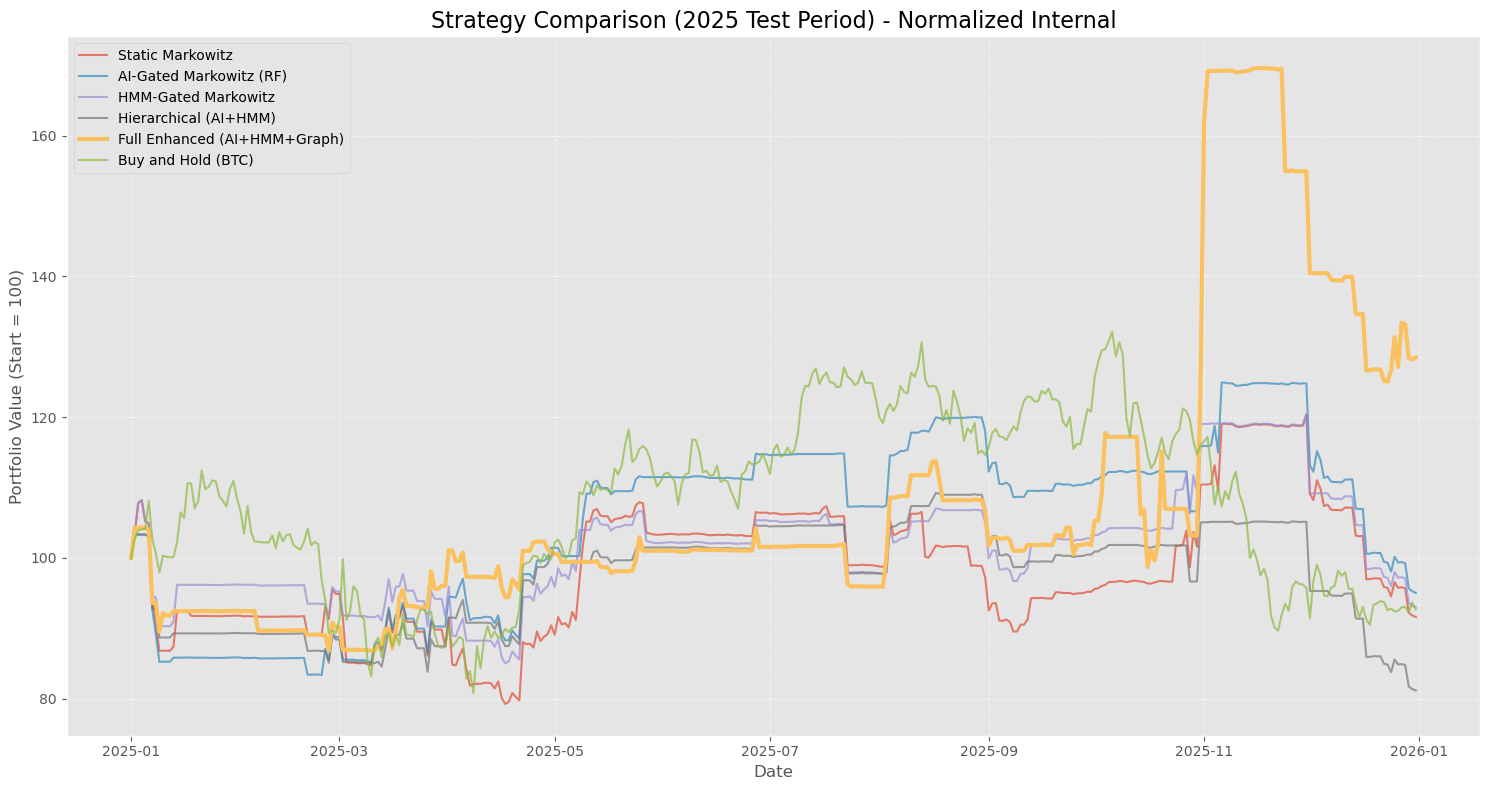

✓ Performance results exported to strategy_performance_v20.xlsx


In [6]:
# --- 5. Visualization ---
plt.figure(figsize=(15, 8))
for label, df in results.items():
    linewidth = 3 if label == 'Full Enhanced (AI+HMM+Graph)' else 1.5
    alpha = 1.0 if label == 'Full Enhanced (AI+HMM+Graph)' else 0.7
    plt.plot(df.index, df['Portfolio_Value'], label=label, linewidth=linewidth, alpha=alpha)

plt.title('Strategy Comparison (2025 Test Period) - Normalized Internal', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Start = 100)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 6. Export to Excel ---
export_df = pd.concat([df.rename(columns={'Portfolio_Value': label}) for label, df in results.items()], axis=1)
export_file = 'strategy_performance_v20.xlsx'
export_df.to_excel(export_file)
print(f"✓ Performance results exported to {export_file}")